# Crop Recommendation — Random Forest
**Dataset:** 2200 samples | 22 crops | 7 features | 0 nulls  
**Goal:** Train, evaluate, and serialize a production-ready RF classifier.

## 0. Imports & Reproducibility

In [2]:
pip install numpy pandas matplotlib seaborn scikit-learn joblib

Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
You should consider upgrading via the 'c:\Users\PCC\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, warnings

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, RandomizedSearchCV
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

SEED = 42
np.random.seed(SEED)
warnings.filterwarnings('ignore')

os.makedirs('artifacts', exist_ok=True)   # model + encoder saved here
print('Imports OK')

Imports OK


## 1. Load & Validate Data

In [21]:
CSV_PATH = 'Crop_recommendation.csv'   # <-- adjust path if needed

df = pd.read_csv(CSV_PATH)

# ── Sanity loop: keep checking until all assertions pass ──
assert df.shape == (2200, 8),         f'Unexpected shape: {df.shape}'
assert df.isnull().sum().sum() == 0,  'Nulls detected — investigate!'
assert df['label'].nunique() == 22,   f'Expected 22 classes, got {df["label"].nunique()}'
assert (df['label'].value_counts() == 100).all(), 'Class imbalance detected!'

print('All data assertions passed ✓')
print(f'Shape : {df.shape}')
print(f'Crops : {sorted(df["label"].unique())}')
df.describe()

All data assertions passed ✓
Shape : (2200, 8)
Crops : ['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee', 'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize', 'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'pomegranate', 'rice', 'watermelon']


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


## 2. EDA — Feature Distributions

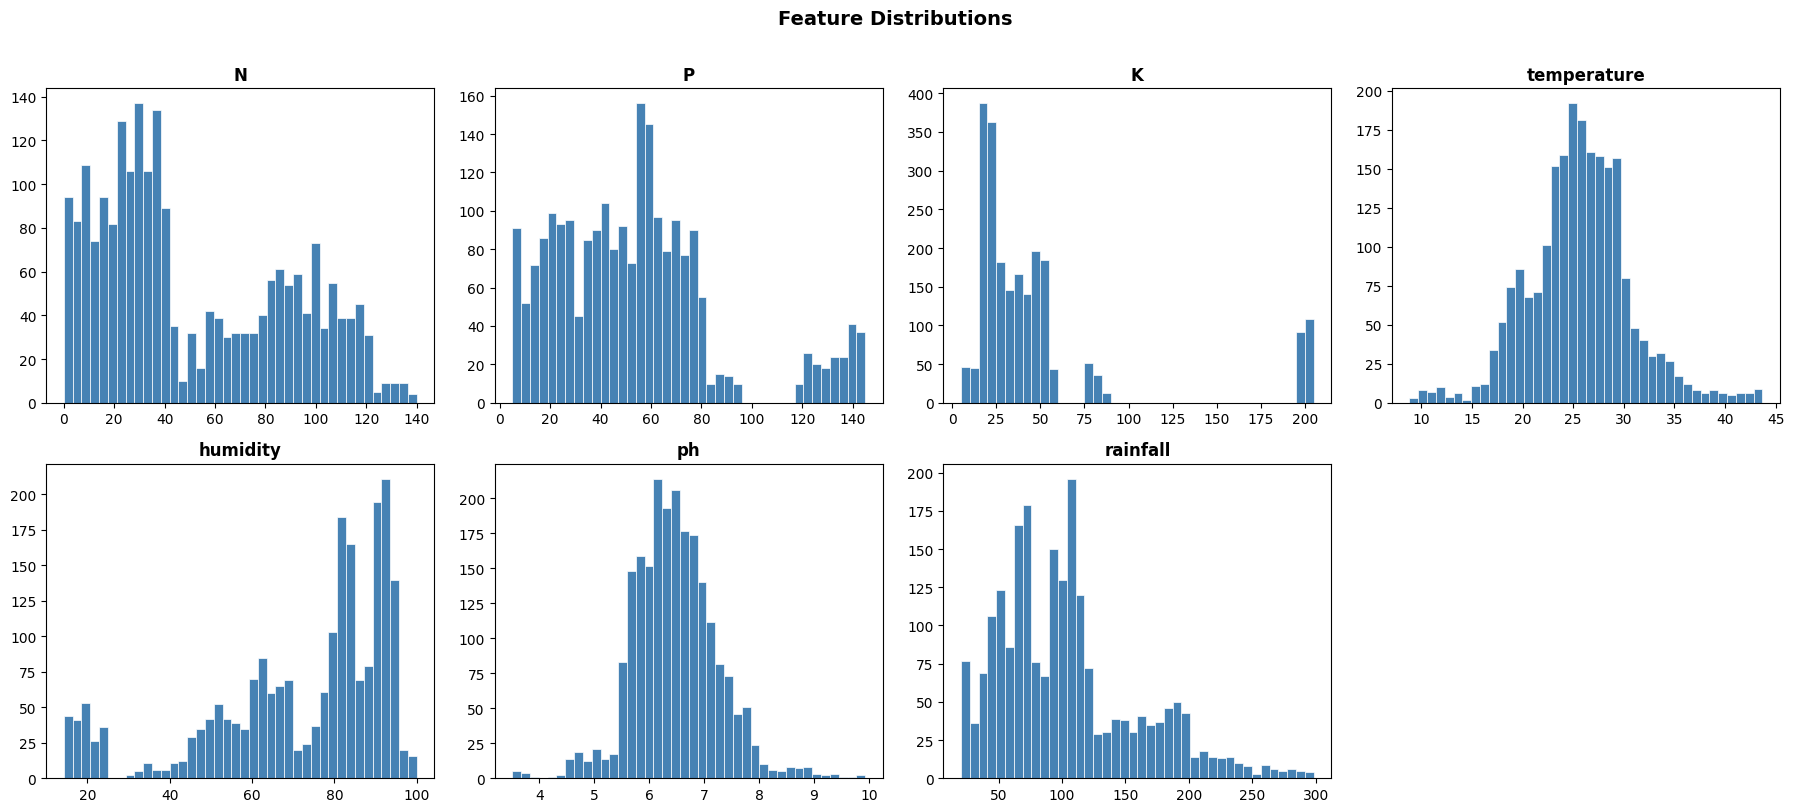

In [22]:
FEATURES = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    axes[i].hist(df[feat], bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
    axes[i].set_title(feat, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')

axes[-1].axis('off')
plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('artifacts/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

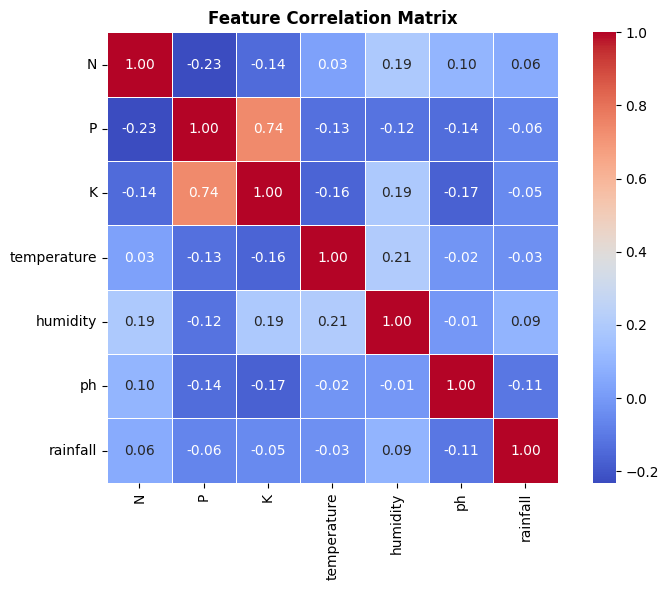

In [23]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[FEATURES].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, square=True)
ax.set_title('Feature Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('artifacts/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Preprocessing

In [24]:
# Encode target
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])

X = df[FEATURES].values
y = df['label_enc'].values

# RF is scale-invariant, but we save the scaler for the Flask app
# (so app users get normalised inputs too — optional but good practice)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Stratified split — preserves 100-per-class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f'Train : {X_train.shape}  |  Test : {X_test.shape}')

# Verify stratification
unique, counts = np.unique(y_train, return_counts=True)
print(f'Train samples per class — min:{counts.min()}, max:{counts.max()}')

Train : (1760, 7)  |  Test : (440, 7)
Train samples per class — min:80, max:80


## 4. Baseline RF — 5-Fold Stratified CV

In [25]:
baseline_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=SEED,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_scores = cross_val_score(baseline_rf, X_scaled, y, cv=cv, scoring='accuracy')

print(f'CV Accuracy : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Per-fold    : {cv_scores.round(4)}')

# Self-check: if CV < 0.97 something is wrong with data or split
assert cv_scores.mean() > 0.97, f'CV too low ({cv_scores.mean():.3f}) — investigate!'
print('Baseline CV check passed ✓')

CV Accuracy : 0.9959 ± 0.0027
Per-fold    : [0.9955 0.9932 1.     0.9977 0.9932]
Baseline CV check passed ✓


## 5. Hyperparameter Tuning — RandomizedSearchCV

In [26]:
param_dist = {
    'n_estimators'     : [100, 200, 300, 500],
    'max_depth'        : [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2', None],
    'bootstrap'        : [True, False]
}

search = RandomizedSearchCV(
    RandomForestClassifier(random_state=SEED, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=30,
    cv=cv,
    scoring='accuracy',
    random_state=SEED,
    verbose=1,
    n_jobs=-1
)

search.fit(X_train, y_train)

print(f'Best params  : {search.best_params_}')
print(f'Best CV score: {search.best_score_:.4f}')

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params  : {'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20, 'bootstrap': False}
Best CV score: 0.9960


## 6. Final Model — Fit & Evaluate on Held-Out Test Set

In [27]:
best_rf = search.best_estimator_

# Re-fit on full train split
best_rf.fit(X_train, y_train)
y_pred = best_rf.predict(X_test)

test_acc = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {test_acc:.4f}')

# Self-check loop
assert test_acc > 0.97, f'Test accuracy too low ({test_acc:.3f}) — recheck pipeline!'
print('Test accuracy check passed ✓')

print('\n--- Classification Report ---')
print(classification_report(
    y_test, y_pred,
    target_names=le.classes_
))

Test Accuracy: 0.9932
Test accuracy check passed ✓

--- Classification Report ---
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      1.00      0.98        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20

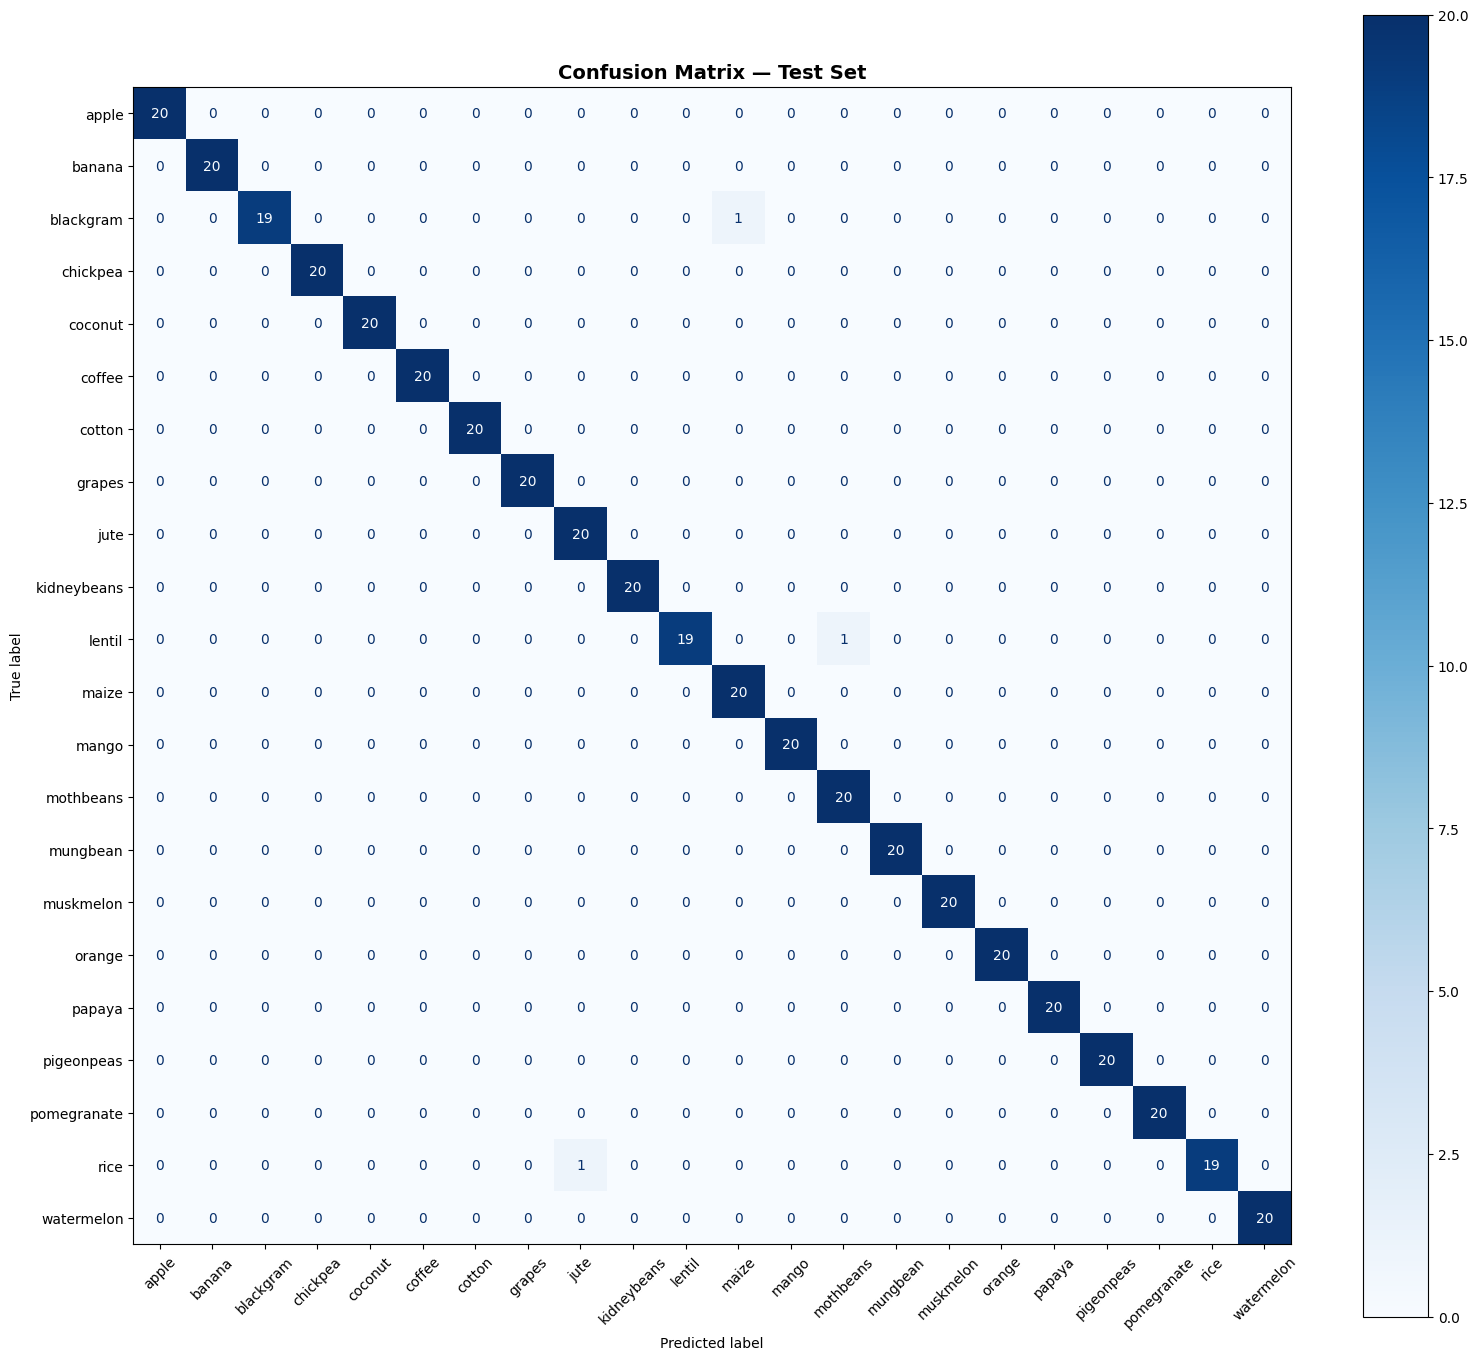

In [28]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(16, 14))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=True, xticks_rotation=45, cmap='Blues')
ax.set_title('Confusion Matrix — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('artifacts/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Feature Importance

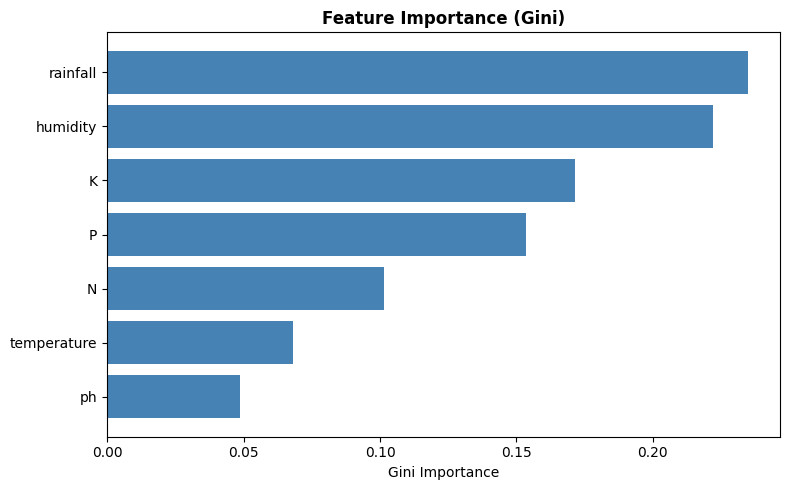

    Feature  Gini Importance
   rainfall         0.234888
   humidity         0.222249
          K         0.171546
          P         0.153386
          N         0.101289
temperature         0.068057
         ph         0.048584


In [29]:
# Gini-based importances (fast, built-in)
gini_imp = best_rf.feature_importances_
imp_df = pd.DataFrame({'Feature': FEATURES, 'Gini Importance': gini_imp})
imp_df = imp_df.sort_values('Gini Importance', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(imp_df['Feature'], imp_df['Gini Importance'], color='steelblue')
ax.set_xlabel('Gini Importance')
ax.set_title('Feature Importance (Gini)', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('artifacts/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(imp_df.to_string(index=False))

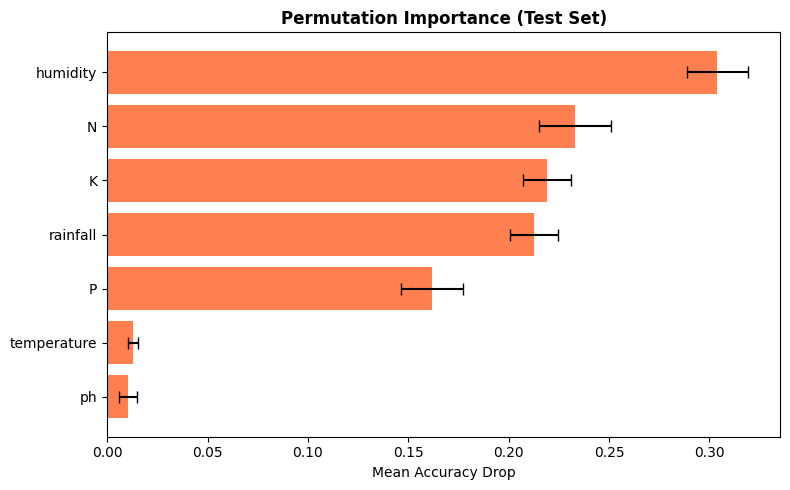

    Feature  Perm Mean  Perm Std
   humidity   0.303939  0.015223
          N   0.233182  0.017892
          K   0.218939  0.011872
   rainfall   0.212576  0.011994
          P   0.161667  0.015456
temperature   0.012727  0.002462
         ph   0.010303  0.004459


In [30]:
# Permutation importance (more reliable, model-agnostic)
perm = permutation_importance(
    best_rf, X_test, y_test,
    n_repeats=15, random_state=SEED, n_jobs=-1
)

perm_df = pd.DataFrame({
    'Feature' : FEATURES,
    'Perm Mean': perm.importances_mean,
    'Perm Std' : perm.importances_std
}).sort_values('Perm Mean', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(
    perm_df['Feature'], perm_df['Perm Mean'],
    xerr=perm_df['Perm Std'], color='coral', capsize=4
)
ax.set_xlabel('Mean Accuracy Drop')
ax.set_title('Permutation Importance (Test Set)', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('artifacts/permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(perm_df.to_string(index=False))

## 8. Serialize Model Artifacts

In [31]:
joblib.dump(best_rf,  'artifacts/rf_model.pkl')
joblib.dump(scaler,   'artifacts/scaler.pkl')
joblib.dump(le,       'artifacts/label_encoder.pkl')

# Verification loop — reload and re-predict, must match
rf_check  = joblib.load('artifacts/rf_model.pkl')
sc_check  = joblib.load('artifacts/scaler.pkl')
le_check  = joblib.load('artifacts/label_encoder.pkl')

sample_raw   = X_test[:5]                         # already scaled
pred_orig    = le.inverse_transform(best_rf.predict(sample_raw))
pred_reload  = le_check.inverse_transform(rf_check.predict(sample_raw))

assert (pred_orig == pred_reload).all(), 'Serialization mismatch — ABORT!'

print('Artifacts serialized and verified ✓')
print(f'Sample predictions: {pred_reload}')
print('\nFiles saved:')
for f in os.listdir('artifacts'):
    print(f'  artifacts/{f}')

Artifacts serialized and verified ✓
Sample predictions: ['orange' 'banana' 'cotton' 'maize' 'orange']

Files saved:
  artifacts/confusion_matrix.png
  artifacts/correlation_matrix.png
  artifacts/feature_distributions.png
  artifacts/feature_importance.png
  artifacts/label_encoder.pkl
  artifacts/permutation_importance.png
  artifacts/rf_model.pkl
  artifacts/scaler.pkl


## 9. Quick Sanity — Manual Inference

In [32]:
# Rice-like inputs — should predict rice
test_input = np.array([[90, 42, 43, 20.9, 82.0, 6.5, 202.9]])
test_scaled = scaler.transform(test_input)
pred_label  = le.inverse_transform(best_rf.predict(test_scaled))[0]
proba       = best_rf.predict_proba(test_scaled)[0]
top3_idx    = np.argsort(proba)[::-1][:3]

print(f'Predicted crop : {pred_label}')
print('Top-3 probabilities:')
for idx in top3_idx:
    print(f'  {le.classes_[idx]:<15} {proba[idx]:.4f}')

Predicted crop : rice
Top-3 probabilities:
  rice            0.9885
  jute            0.0051
  papaya          0.0044


In [34]:
# ================= FULL MODEL EVALUATION =================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)
import matplotlib.pyplot as plt

# Make predictions on your test data
y_pred = rf_model.predict(X_test)

# 1. Accuracy
accuracy = accuracy_score(y_test, y_pred)

# 2. Precision
precision = precision_score(y_test, y_pred, average='weighted')

# 3. Recall
recall = recall_score(y_test, y_pred, average='weighted')

# 4. F1 Score
f1 = f1_score(y_test, y_pred, average='weighted')

# Print results
print("===== MODEL EVALUATION =====")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

# 5. Classification Report
print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, y_pred))

# 6. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\n===== CONFUSION MATRIX =====")
print(cm)

# Display Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

# 7. ROC-AUC
try:
    y_proba = rf_model.predict_proba(X_test)

    auc = roc_auc_score(
        y_test,
        y_proba,
        multi_class='ovr',
        average='weighted'
    )

    print(f"\nROC-AUC Score : {auc:.4f}")

except Exception as e:
    print("\nROC-AUC could not be calculated:", e)

NameError: name 'rf_model' is not defined

In [19]:
print("Model:", type(rf_model))
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

NameError: name 'rf_model' is not defined

In [35]:
pip install nbconvert pyppeteer

Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
You should consider upgrading via the 'c:\Users\PCC\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.
